# 10 · Bayesian EDA and uncertainty summaries

Use Ruddy Bayesian summaries to visualize posterior location, uncertainty, direction and practical-equivalence probabilities without introducing an external Bayesian modeling framework.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'examples' / 'notebooks'))
from _helpers import *
configure_plots()

from ruddy import analyze_bayesian_eda
frame,dataset=load_tabular_demo()
# binary grouping for mean differences
bay=analyze_bayesian_eda(dataset,variables=('activity','stability','length','charge'),groups=('flag',),draws=2500,rope=(-0.15,0.15),random_state=42)
display(bay.means); display(bay.mean_differences)

,variable,n,posterior_mean,posterior_median,credible_low,credible_high,probability_positive,probability_negative,probability_direction,rope_probability,status,reason
0,activity,180,2.416093,2.415356,2.239574,2.597996,1.0000,0.0000,1.0000,0.0000,ok,None
1,stability,180,2.437079,2.437725,2.350416,2.522612,1.0000,0.0000,1.0000,0.0000,ok,None
2,length,180,51.832299,51.821480,50.756495,52.924136,1.0000,0.0000,1.0000,0.0000,ok,None
3,charge,180,0.111402,0.110583,-0.051371,0.279212,0.9052,0.0948,0.9052,0.6748,ok,None


,variable,group,level_a,level_b,n_a,n_b,posterior_mean,posterior_median,credible_low,credible_high,probability_positive,probability_negative,probability_direction,rope_probability,status,reason
0,activity,flag,False,True,90,90,-2.028410,-2.024643,-2.232466,-1.824971,0.0000,1.0000,1.0000,0.0000,ok,None
1,stability,flag,False,True,90,90,0.104980,0.103493,-0.066917,0.274200,0.8812,0.1188,0.8812,0.6872,ok,None
2,length,flag,False,True,90,90,-4.641158,-4.657801,-6.758883,-2.517725,0.0000,1.0000,1.0000,0.0000,ok,None
3,charge,flag,False,True,90,90,-0.009443,-0.009873,-0.346042,0.332142,0.4772,0.5228,0.5228,0.6024,ok,None


## Posterior location with credible intervals

findfont: Failed to find font weight semibold, now using 700.


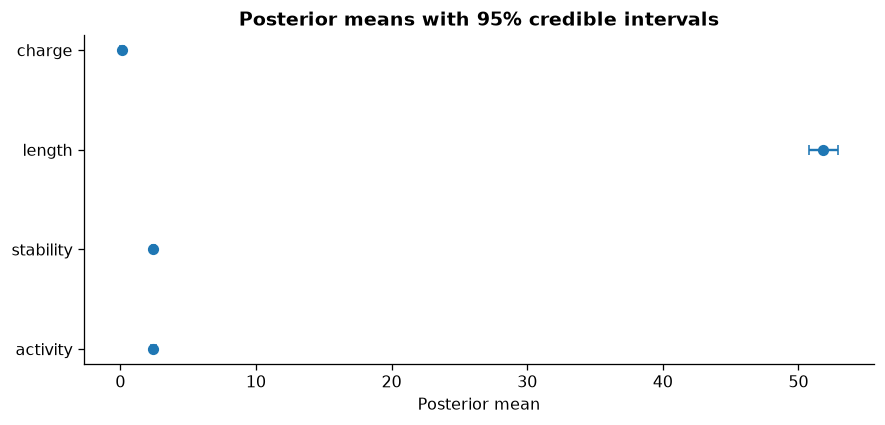

In [2]:
m=bay.means.query('status=="ok"').copy(); errorbar_table(m,label_col='variable',estimate_col='posterior_mean',low_col='credible_low',high_col='credible_high',title='Posterior means with 95% credible intervals',xlabel='Posterior mean',zero_line=False); plt.show()

## Binary-group posterior differences

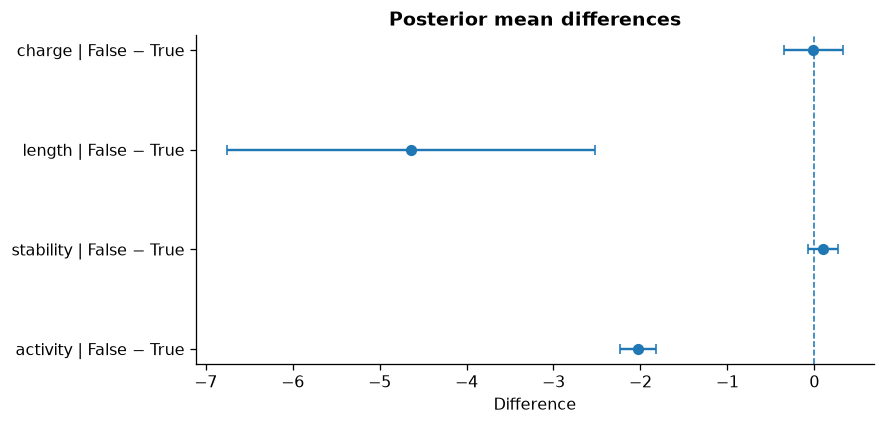

In [3]:
d=bay.mean_differences.query('status=="ok"').copy(); d['contrast']=d.variable+' | '+d.level_a.astype(str)+' − '+d.level_b.astype(str); errorbar_table(d,label_col='contrast',estimate_col='posterior_mean',low_col='credible_low',high_col='credible_high',title='Posterior mean differences',xlabel='Difference'); plt.show()

## Probability of direction and ROPE probability

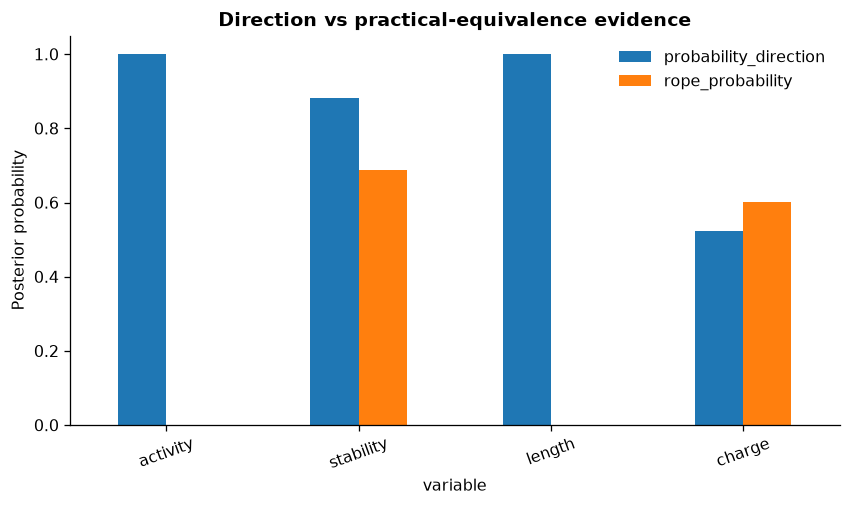

In [4]:
summary=d.set_index('variable')[['probability_direction','rope_probability']]; fig,ax=plt.subplots(figsize=(7.5,4.5)); summary.plot(kind='bar',ax=ax); ax.set_ylim(0,1.05); ax.set_ylabel('Posterior probability'); ax.set_title('Direction vs practical-equivalence evidence'); ax.tick_params(axis='x',rotation=20); finish(fig); plt.show()

## Posterior sign probabilities

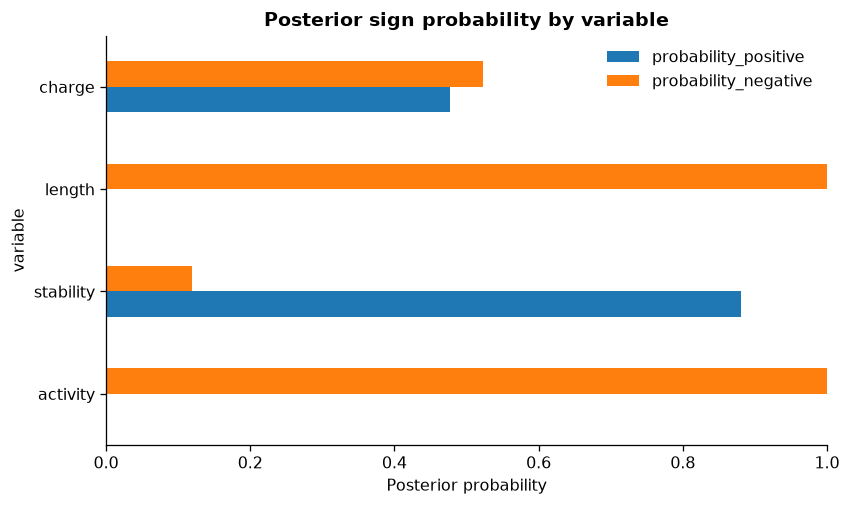

In [5]:
sg=d.set_index('variable')[['probability_positive','probability_negative']]; fig,ax=plt.subplots(figsize=(7.5,4.5)); sg.plot(kind='barh',ax=ax); ax.set_xlim(0,1); ax.set_xlabel('Posterior probability'); ax.set_title('Posterior sign probability by variable'); finish(fig); plt.show()